<a href="https://colab.research.google.com/github/ariefpurnamamuharram/ariefpurnamamuharram.github.io/blob/master/files/T2_2_ImplVis_23521013_Arief_Purnama_Muharram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T2 - Implementasi Dataviz (Tahap 2)
___
Name: Arief Purnama Muharram<br>
NIM: 23521013

## Step 0: Prerequisite

### 0.1: Install required packages

In [ ]:
!pip install numpy
!pip install pandas
!pip install seaborn

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# Print library versions

import pandas as pd
import numpy as np
import seaborn as sns

print('pandas', pd.__version__)
print('numpy', np.__version__)
print('seaborn', sns.__version__)

pandas 1.3.5
numpy 1.21.6
seaborn 0.11.2


## Step 1: Import Dataset

In [ ]:
# Import dataset 

import pandas as pd


df = pd.read_csv('data.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fage            829 non-null    float64
 1   mage            1000 non-null   int64  
 2   mature          1000 non-null   object 
 3   weeks           998 non-null    float64
 4   premie          998 non-null    object 
 5   visits          991 non-null    float64
 6   marital         999 non-null    object 
 7   gained          973 non-null    float64
 8   weight          1000 non-null   float64
 9   lowbirthweight  1000 non-null   object 
 10  gender          1000 non-null   object 
 11  habit           999 non-null    object 
 12  whitemom        998 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 101.7+ KB


   Dataset attribute information:<br>
*   fage – father's age in years.
*   mage – mother's age in years.
*   mature – maturity status of mother.
*   weeks – length of pregnancy in weeks.
*   premie – whether the birth was classied as premature (premie) or full-term.
*   visits – number of hospital visits during pregnancy.
*   gained – weight gained by mother during pregnancy in pounds.
*   weight – weight of the baby at birth in pounds.
*   lowbirthweight – whether baby was classied as low birthweight (low) or not (not low).
*   gender – gender of the baby, female or male.
*   habit – status of the mother as a nonsmoker or a smoker.
*   marital – whether mother is married or not married at birth.
*   whitemom – whether mom is white or not white.

In [ ]:
# Describe dataset 

df.describe()

,fage,mage,weeks,visits,gained,weight
count,829.000000,1000.000000,998.000000,991.000000,973.000000,1000.00000
mean,30.255730,27.000000,38.334669,12.104945,30.325797,7.10100
std,6.763766,6.213583,2.931553,3.954934,14.241297,1.50886
min,14.000000,13.000000,20.000000,0.000000,0.000000,1.00000
25%,25.000000,22.000000,37.000000,10.000000,20.000000,6.38000
50%,30.000000,27.000000,39.000000,12.000000,30.000000,7.31000
75%,35.000000,32.000000,40.000000,15.000000,38.000000,8.06000
max,55.000000,50.000000,45.000000,30.000000,85.000000,11.75000


In [ ]:
# Print dataset sample 

df.head(3)

,fage,mage,mature,weeks,premie,visits,marital,gained,weight,lowbirthweight,gender,habit,whitemom
0,NaN,13,younger mom,39.0,full term,10.0,not married,38.0,7.63,not low,male,nonsmoker,not white
1,NaN,14,younger mom,42.0,full term,15.0,not married,20.0,7.88,not low,male,nonsmoker,not white
2,19.0,15,younger mom,37.0,full term,11.0,not married,38.0,6.63,not low,female,nonsmoker,white


## Step 2: Data Preprocessing

### 2.1: Print unique values from each attributes

In [ ]:
for column in list(df.columns):
  print(column + ':', df[column].unique(), '\n')

fage: [nan 19. 21. 18. 17. 20. 30. 14. 16. 26. 31. 28. 25. 23. 24. 22. 32. 27.
 29. 36. 38. 33. 35. 34. 41. 44. 43. 45. 47. 46. 42. 37. 40. 39. 48. 53.
 50. 55.] 

mage: [13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36
 37 38 39 40 41 42 45 46 50] 

mature: ['younger mom' 'mature mom'] 

weeks: [39. 42. 37. 41. 38. 35. 45. 40. 24. 36. 29. 31. 43. 44. 33. 30. 34. 22.
 32. 25. 26. nan 28. 20.] 

premie: ['full term' 'premie' nan] 

visits: [10. 15. 11.  6.  9. 19. 12.  5. 13.  8.  4.  7. 17.  3. 16. nan 14.  0.
 18.  2. 23. 30. 20. 22. 24. 25. 26.] 

marital: ['not married' 'married' nan] 

gained: [38. 20. 34. 27. 22. 76. 15. nan 52. 28. 12. 30. 75. 35.  9. 39. 40. 36.
 50. 68. 72. 25. 10.  1. 11. 41. 48. 57. 60. 18. 23. 26. 32. 56. 13. 47.
 17. 33.  4. 16.  0. 46. 51. 55. 37.  5. 24. 19. 29. 70. 14. 31. 45. 21.
  6.  2. 62. 58. 65. 80. 85. 54.  8. 53. 44. 43. 61.  3. 42. 59.  7. 77.] 

weight: [ 7.63  7.88  6.63  8.    6.38  5.38  8.44  4.69  8.81  6.94  7.44  6

### 2.2: Null checking

In [ ]:
import numpy as np


for column in list(df.columns):
  if str(df[column].dtype) == 'float64':
    if True in np.isnan(list(df[column].unique())):
      print(column)
  else:
    if np.nan in list(df[column]):
      print(column)

fage
weeks
premie
visits
marital
gained
habit
whitemom


### 2.3: Null values treatment
Asumsi heuristik:<br>
*   Kolom-kolom yang mengandung nilai *null* (NaN) yaitu *fage*, *weeks*, *premie*, *visits*, *marital*, *gained*, *habit*, dan *whitemom*.
*   Kolom yang dapat ditangani dengan pendekatan nilai rata-rata: *fage*, *weeks*, *visits*, dan *gained*.
*   Kolom yang dapat ditangani dengan pendekatan nilai yang sering muncul (modus): *marital*, *habit*, dan *whitemom*.

In [ ]:
# Treating null values with average value of the attribute 

import numpy as np


for column in ['fage', 'weeks', 'visits', 'gained']:
  df[column].replace(np.nan, int(df[column].mean()), inplace=True)

In [ ]:
# Treating null values with mode value of the attribute 

import numpy as np


for column in ['marital', 'habit', 'whitemom']:
  df[column].replace(np.nan, df[column].mode()[0], inplace=True)

### 2.4: Duplicate checking

In [ ]:
df.duplicated().any()

False

## Step 3: Data Visualisation

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')

### 3.1: Jumlah Bayi Lahir Berdasarkan Usia Ibu

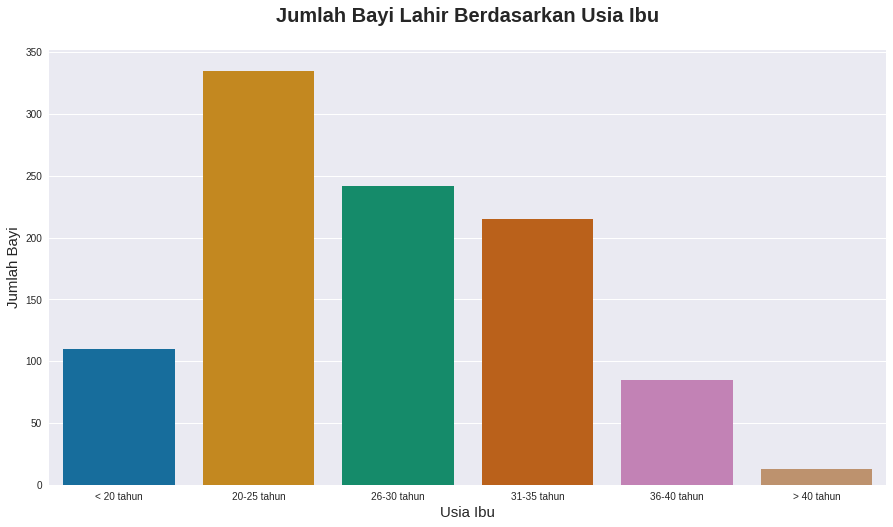

In [ ]:
def cat_mage(age):
  if age < 20:
    return '< 20 tahun'
  elif age >= 20 and age <= 25:
    return '20-25 tahun'
  elif age >= 26 and age <= 30:
    return '26-30 tahun'
  elif age >= 31 and age <= 35:
    return '31-35 tahun'
  elif age >= 36 and age <= 40:
    return '36-40 tahun'
  else:
    return '> 40 tahun'

df['cat_mage'] = df['mage'].apply(lambda x: cat_mage(x))

plt.style.use('seaborn')
plt.figure(figsize=(15,8))
sns.countplot(data=df, x='cat_mage', palette='colorblind')
plt.title('Jumlah Bayi Lahir Berdasarkan Usia Ibu\n', fontdict={
    'fontsize': 20, 'fontweight': 'bold'
})
plt.xlabel('Usia Ibu', fontdict={
    'fontsize': 15
})
plt.ylabel('Jumlah Bayi', fontdict={
    'fontsize': 15
})
plt.show()

Justifikasi penggunaan visualisasi:<br>
*   *Countplot* digunakan untuk menampilkan jumlah data observasi pada setiap kategori menggunakan pendekatan visualisasi batang *(bar)*.
*   Tipe data yang hendak divisualisasikan bertipe kategori sehingga penggunaan *countplot* cocok.
*   Penggunaan palet warna *colorblind* bertujuan agar warna kategori yang dihasilkan ramah bagi penyandang *Colour Vision Deficiency* (CVD).

*Insight* yang diperoleh:<br>
*   Tiga peringkat kategori usia ibu dengan jumlah bayi terbanyak yaitu usia 20-25 tahun, 26-30 tahun, dan 31-35 tahun.
*   Usia ibu hamil optimal berkisar di rentang usia 20-30 tahun. Memasuki usia 31-35 tahun sudah terdapat beberapa faktor risiko, tetapi hamil pada usia tersebut masih diperbolehkan. Dengan demikian, sebagian besar usia ibu hamil pada populasi *dataset* masih tergolong baik.
*   Tinginya jumlah ibu hamil di kategori usia kurang dari 20 tahun dan lebih dari 35 tahun memerlukan penyelidikan lebih lanjut dan perhatian khusus. Usia ibu hamil pada rentang tersebut rentan terhadap berbagai faktor risiko yang dapat memengaruhi kesehatan ibu dan anak.

### 3.2: Jumlah Bayi Lahir Prematur Berdasarkan Usia Kehamilan

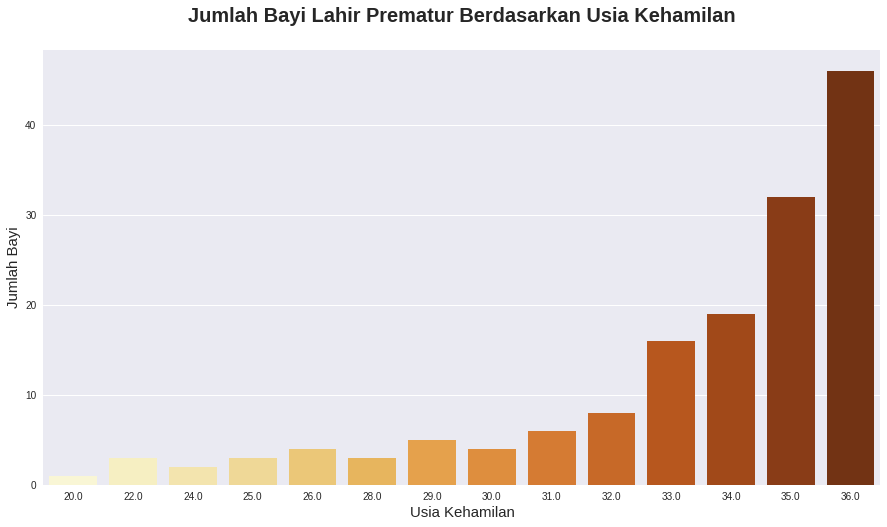

In [ ]:
plt.style.use('seaborn')
plt.figure(figsize=(15,8))
sns.countplot(data=df[df['premie'] == 'premie'], x='weeks', palette='YlOrBr')
plt.title('Jumlah Bayi Lahir Prematur Berdasarkan Usia Kehamilan\n', fontdict={
    'fontsize': 20, 'fontweight': 'bold'
})
plt.xlabel('Usia Kehamilan', fontdict={
    'fontsize': 15
})
plt.ylabel('Jumlah Bayi', fontdict={
    'fontsize': 15
})
plt.show()

Justifikasi penggunaan visualisasi:<br>
*   *Countplot* digunakan untuk menampilkan jumlah data observasi pada setiap kategori menggunakan pendekatan visualisasi batang *(bar)*.
*   Tipe data yang hendak divisualisasikan bertipe kategori sehingga penggunaan *countplot* cocok.
*   Penggunaan palet warna "YlOrBr" bertujuan untuk memberikan gradasi warna yang sesuai dengan jumlah data.

*Insight* yang diperoleh:<br>
*   Tiga peringkat kategori usia kehamilan dengan jumlah bayi prematur terbanyak yaitu usia 36, 35, dan 34 minggu.
*   Semakin rendah usia kehamilan ibu pada saat melahirkan bayi prematur maka semakin tinggi faktor risiko yang mungkin terjadi dan semakin rendah *survival rate*.
*   Bayi yang lahir di bawah usia kehamilan 33 minggu perlu mendapatkan penyelidikan dan perhatian khusus, baik pada faktor ibu maupun bayinya.

### 3.3: Jumlah Bayi Lahir Prematur Berdasarkan Usia Ibu

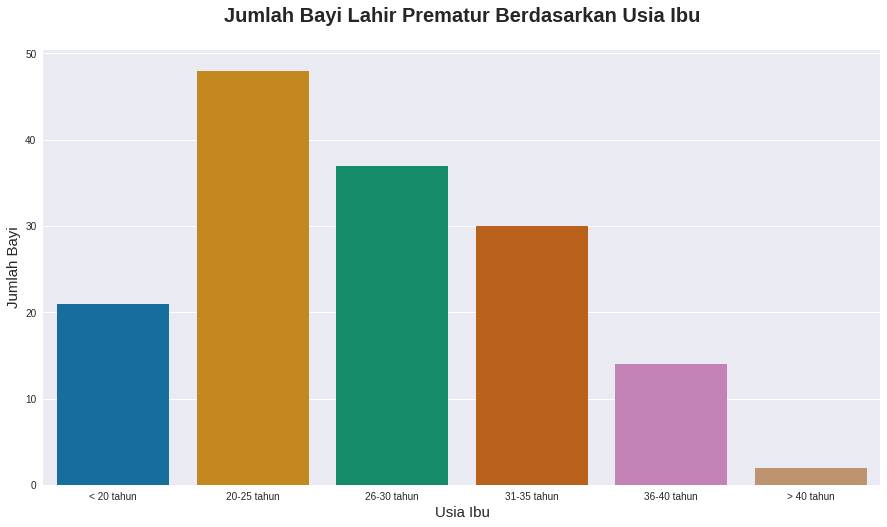

In [ ]:
plt.style.use('seaborn')
plt.figure(figsize=(15,8))
sns.countplot(data=df[df['premie'] == 'premie'], x='cat_mage', palette='colorblind')
plt.title('Jumlah Bayi Lahir Prematur Berdasarkan Usia Ibu\n', fontdict={
    'fontsize': 20, 'fontweight': 'bold'
})
plt.xlabel('Usia Ibu', fontdict={
    'fontsize': 15
})
plt.ylabel('Jumlah Bayi', fontdict={
    'fontsize': 15
})
plt.show()

Justifikasi penggunaan visualisasi:<br>
*   *Countplot* digunakan untuk menampilkan jumlah data observasi pada setiap kategori menggunakan pendekatan visualisasi batang *(bar)*.
*   Tipe data yang hendak divisualisasikan bertipe kategori sehingga penggunaan *countplot* cocok.
*   Penggunaan palet warna *colorblind* bertujuan agar warna kategori yang dihasilkan ramah bagi penyandang *Colour Vision Deficiency* (CVD).

*Insight* yang diperoleh:<br>
*   Tiga peringkat kategori usia ibu dengan jumlah bayi prematur terbanyak yaitu usia 20-25 tahun, 26-30 tahun, dan 31-35 tahun.

### 3.4: Jumlah Bayi Lahir Prematur Berdasarkan Kebiasaan Ibu

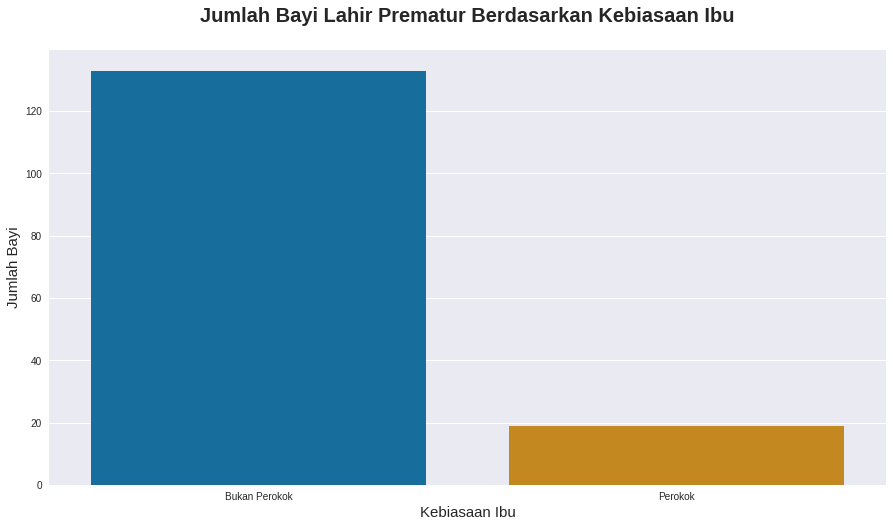

In [ ]:
df['habit'] = df['habit'].astype('category')
df['habit'] = df['habit'].cat.rename_categories({'nonsmoker': 'Bukan Perokok', 'smoker': 'Perokok'})

plt.style.use('seaborn')
plt.figure(figsize=(15,8))
sns.countplot(data=df[df['premie'] == 'premie'], x='habit', palette='colorblind')
plt.title('Jumlah Bayi Lahir Prematur Berdasarkan Kebiasaan Ibu\n', fontdict={
    'fontsize': 20, 'fontweight': 'bold'
})
plt.xlabel('Kebiasaan Ibu', fontdict={
    'fontsize': 15
})
plt.ylabel('Jumlah Bayi', fontdict={
    'fontsize': 15
})
plt.show()

Justifikasi penggunaan visualisasi:<br>
*   *Countplot* digunakan untuk menampilkan jumlah data observasi pada setiap kategori menggunakan pendekatan visualisasi batang *(bar)*.
*   Tipe data yang hendak divisualisasikan bertipe kategori sehingga penggunaan *countplot* cocok.
*   Penggunaan palet warna *colorblind* bertujuan agar warna kategori yang dihasilkan ramah bagi penyandang *Colour Vision Deficiency* (CVD).

*Insight* yang diperoleh:<br>
Sebagian besar bayi lahir prematur pada populasi *dataset* berasal dari ibu tanpa kebiasaan merokok. Hal ini mungkin menunjukan bahwa kejadian bayi lahir prematur tidak berkaitan langsung dengan kebiasaan merokok ibu.

### 3.5: (Soal Bonus) Hubungan Peningkatan Berat Badan Ibu Terhadap Usia Kehamilan pada Ibu dengan Bayi Lahir Prematur

<Figure size 1080x576 with 0 Axes>

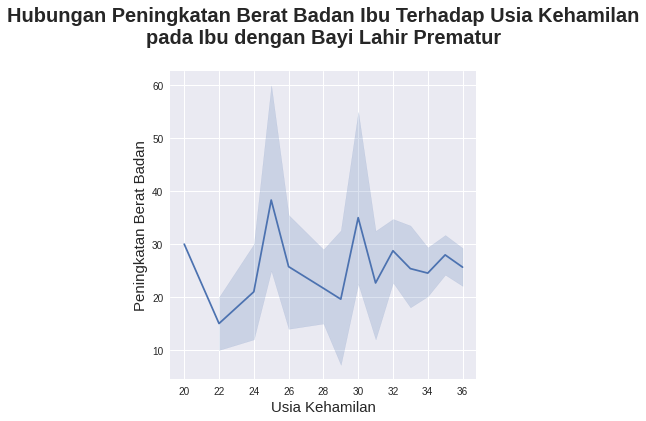

In [ ]:
plt.style.use('seaborn')
plt.figure(figsize=(15,8))
sns.relplot(data=df[df['premie'] == 'premie'], x='weeks', y='gained', kind='line')
plt.title('Hubungan Peningkatan Berat Badan Ibu Terhadap Usia Kehamilan\npada Ibu dengan Bayi Lahir Prematur\n', fontdict={
    'fontsize': 20, 'fontweight': 'bold'
})
plt.xlabel('Usia Kehamilan', fontdict={
    'fontsize': 15
})
plt.ylabel('Peningkatan Berat Badan', fontdict={
    'fontsize': 15
})
plt.show()

Justifikasi penggunaan visualisasi:<br>
*   *Relplot* digunakan pada kasus ini untuk menampilkan hubungan antar variabel. Dalam hal ini digunakan untuk memvisualisasikan hubungan antara peningkatan berat badan ibu terhadap usia kehamilan.

*Insight* yang diperoleh:<br>
Ekspektasi yang diharapkan dari hubungan antara peningkatan berat badan terhadap usia kehamilan yaitu bersifat linear. Semakin tinggi usia kehamilan maka diharapkan berat badan semakin meningkat. Akan tetapi, pada ibu yang melahirkan bayi prematur hubungan cenderung fluktuatif. Hal tersebut dapat mengindikasikan adanya gangguan nutrisi selama hamil pada ibu tersebut sehingga menyebabkan bayi lahir secara prematur.